# Simulations de Monte Carlo

In [7]:
import numpy as np
import random as rd
import matplotlib.pyplot as plt

Une marche aléatoire peut permettre de modéliser un prix. Pour passer du prix à l'instant n au prix à l'instant n+1, la différence de prix suit une certaine loi (dans notre exemple, une loi normale de variance 100 et de moyenne 0). 

La probabilité de valoir un certain prix en t = n+1 dépend a priori de la valeur de la marche à tous les instants t = 0, ..., n. Ex : en cas de krach boursier, la valeur du prix au bout de 4 jours dépend du prix au début du krach (t=0) et de la dynamique du krach.

=> Si on note Xt le prix à l'instant t, on a ainsi : la probabilité que le prix vaille k à un instant p dépend des prix aux instants 1, ..., t-1 : p( (Xt=k) I (X1=i), (X2=j), ... (Xt-1 = l)) 

Pour simplifier, on se place souvent dans un modèle de Markov : le prix à l'instant t+1 dépend UNIQUEMENT du prix à l'instant t (comme si toute l'information sur le krach avait été prise en compte dans la valeur du prix à l'instant t).
p( (Xt=k) I (X1=i), (X2=j), ... (Xt-1 = l)) = p( (Xt=k) I (Xt-1=i) )

Dans ce cas, à chaque pas de temps, la transition d'un prix à l'autre se fait selon une loi simple. Dans notre modèle, une loi gaussienne N(0, 100).

# Données observées 

In [18]:
X = np.random.normal(0,100,100)

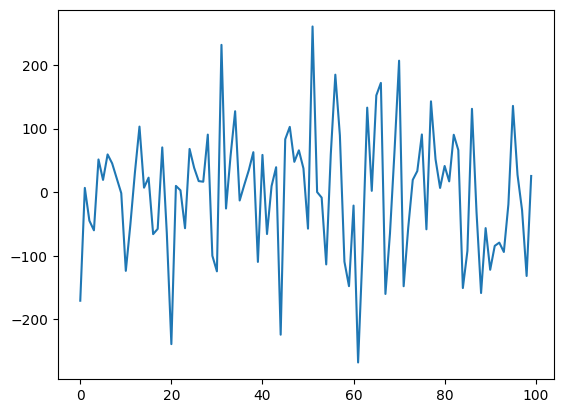

In [19]:
plt.plot(X)

# But

Méthode de Monte Carlo (le nom vient du Casino de Monte Carlo à Monaco où il y a bcp de jeux aléatoires)

Le principe est le suivant : on connaît l'évolution du prix d'une action pendant les 100 premiers pas de temps. On aimerait pricer une option sur cette action. Pour ça, on veut connaître une estimation de son prix dans 100 pas de temps supplémentaire. Si son prix est élevé, on pourra vendre l'option plus chère par exemple. 

Une méthode simple pour faire ça consiste à faire un modèle des données sur les 100 premiers pas de temps, puis échantillonner ce modèle (trouver une réalisation qui suit ce même modèle) pendant les 100 pas de temps suivants. Si on échantillonne le modèle beaucoup de fois et que notre modèle n'est pas trop mauvais, on peut regarder le prix moyen de l'action après les 100 pas de temps supplémentaires, et il devrait être proche de ce que va vraiment valoir l'action.

Dans cet exemple, on commence avec un très mauvais modèle de notre prix sur les 100 premiers pas de temps : on voit que ça ne colle pas, et le prix moyen qu'on va trouver sera mauvais.

# Premier modèle des données observées

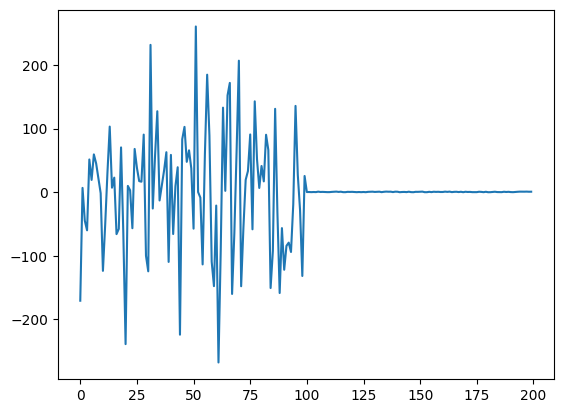

In [21]:
Y = np.append(X,np.random.random(100))
plt.plot(Y)

# Modèle un peu mieux

On se rapproche un peu plus de ce que fait vraiment le modèle (dans la vraie vie, on ne le connaît pas donc on essaie plusieurs modèles jusqu'à en trouver un qui a l'air plausible)

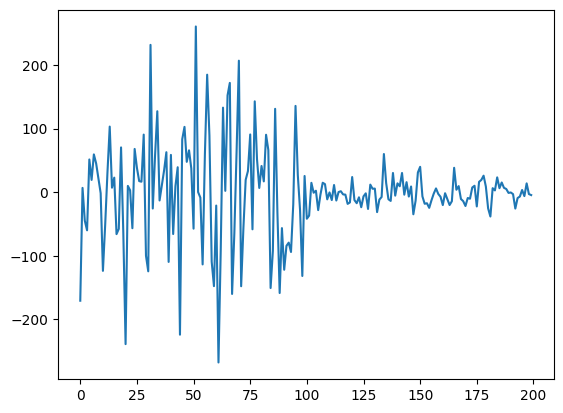

In [23]:
Z = np.append(X,np.random.normal(0, 20,100))
plt.plot(Z)

# Modèle parfait

Ce modèle là a l'air bien, on va le garder comme modèle pour faire nos simulations

(en supposant que les conditions de marché mesurées pour t dans [0, 100] seront les mêmes pour t dans [101, 200])

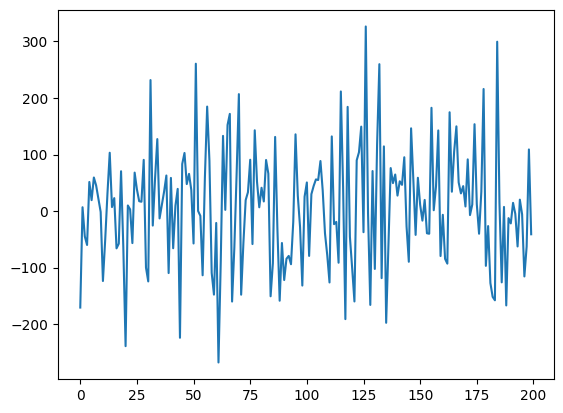

In [29]:
B = np.append(X,np.random.normal(0, 100,100))
plt.plot(B)

# Simulations

Ensuite, on simule plusieurs réalisations de ce modèle

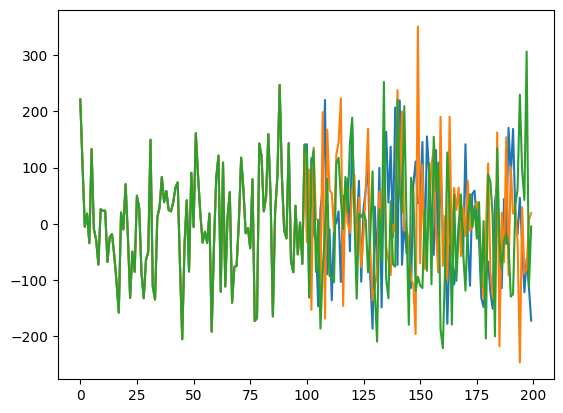

In [32]:
A = np.random.normal(0,100,100)
W1 = np.append(A,np.random.normal(0, 100,100))
W2 = np.append(A,np.random.normal(0, 100,100))
W3 = np.append(A,np.random.normal(0, 100,100))

plt.plot(W1)
plt.plot(W2)
plt.plot(W3)

# Estimation du paramètre

Chaque échantillon nous done une valeur finale de l'action après les 100 pas de temps supplémentaires. On prend la valeur moyenne des valeurs finales : moyenne = (verte_fin + orange_fin + bleue_fin) / 3

Ça devrait être plus ou moins égal au prix espéré (sous l'hypothèse selon laquelle les conditions du marché n'ont pas changé. Par exemple, si un krach boursier arrive au pas de temps 150, le modèle qu'on aura estimé sur les pas de temps 0 à 100 sera mauvais. On peut faire plusieurs scénarios différents (avec ou sans krach) et pondérer les valeurs finales qu'ils donnent par la probabilité qu'ils arrivent 